#  8×8 Jigsaw Reconstruction

This notebook demonstrates the **Multi-Strategy Puzzle Solver** for 8×8 puzzles.

### System Capabilities:
- **Robust Matching:** Uses color and gradient metrics.
- **Multiple Approaches:** Runs 5 different reconstruction algorithms and picks the best one.
- **Refinement:** Polishes the final result for better alignment.

### Demonstration:
-  **Standard Case:** Puzzle #1
-  **Complex Case:** Puzzle #0 (Low Texture)
-  **Analytics:** Visualization of matching metrics.

In [1]:
import cv2
import numpy as np
import os
import random
import math
import matplotlib.pyplot as plt

plt.style.use('dark_background')
%matplotlib inline

In [2]:
# Standard Jigsaw Solver Implementation
def sort_key(f):
    name = f.replace('piece_', '').split('.')[0]
    return int(name) if name.isdigit() else name

def load_pieces(folder):
    if not os.path.exists(folder): return None
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg'))], key=sort_key)
    return [cv2.imread(os.path.join(folder, f)) for f in files]

class JigsawSolver:
    def __init__(self, pieces):
        self.pieces = pieces
        self.n = len(pieces)
        self.lab = [cv2.cvtColor(p, cv2.COLOR_BGR2LAB).astype(np.float32) for p in pieces]
        self.compute_all_metrics()
        self.find_all_buddies()
    
    def lab_ssd(self, i, j, direction, width=1):
        if direction == 'right':
            e1 = self.lab[i][:, -width:, :]
            e2 = self.lab[j][:, :width, :]
        else:
            e1 = self.lab[i][-width:, :, :]
            e2 = self.lab[j][:width, :, :]
        return np.sum((e1 - e2) ** 2) / e1.size
    
    def paikin_dissim(self, i, j, direction):
        if direction == 'right':
            pred = 2 * self.lab[i][:, -1, :] - self.lab[i][:, -2, :]
            actual = self.lab[j][:, 0, :]
        else:
            pred = 2 * self.lab[i][-1, :, :] - self.lab[i][-2, :, :]
            actual = self.lab[j][0, :, :]
        return np.sum(np.abs(pred - actual))
    
    def compute_all_metrics(self):
        n = self.n
        self.rc1 = np.full((n, n), np.inf)
        self.bc1 = np.full((n, n), np.inf)
        self.rc2 = np.full((n, n), np.inf)
        self.bc2 = np.full((n, n), np.inf)
        self.rc_p = np.full((n, n), np.inf)
        self.bc_p = np.full((n, n), np.inf)
        
        for i in range(n):
            for j in range(n):
                if i != j:
                    self.rc1[i, j] = self.lab_ssd(i, j, 'right', 1)
                    self.bc1[i, j] = self.lab_ssd(i, j, 'down', 1)
                    self.rc2[i, j] = self.lab_ssd(i, j, 'right', 2)
                    self.bc2[i, j] = self.lab_ssd(i, j, 'down', 2)
                    self.rc_p[i, j] = self.paikin_dissim(i, j, 'right')
                    self.bc_p[i, j] = self.paikin_dissim(i, j, 'down')
        
        self.rc = 0.6 * self.rc1 + 0.4 * self.rc2
        self.bc = 0.6 * self.bc1 + 0.4 * self.bc2
    
    def find_all_buddies(self):
        n = self.n
        
        self.hb1, self.vb1 = {}, {}
        for a in range(n):
            b = np.argmin(self.rc1[a, :])
            if np.argmin(self.rc1[:, b]) == a: self.hb1[a] = b
        for a in range(n):
            b = np.argmin(self.bc1[a, :])
            if np.argmin(self.bc1[:, b]) == a: self.vb1[a] = b
        
        self.hb_p, self.vb_p = {}, {}
        for a in range(n):
            b = np.argmin(self.rc_p[a, :])
            if np.argmin(self.rc_p[:, b]) == a: self.hb_p[a] = b
        for a in range(n):
            b = np.argmin(self.bc_p[a, :])
            if np.argmin(self.bc_p[:, b]) == a: self.vb_p[a] = b
        
        self.hb = {k: v for k, v in self.hb1.items() if self.hb_p.get(k) == v}
        self.vb = {k: v for k, v in self.vb1.items() if self.vb_p.get(k) == v}
        
    def evaluate(self, sol, metric='combined'):
        grid = np.array(sol).reshape((8, 8))
        total = 0
        bb = 0
        
        if metric == 'lab1':
            rc, bc = self.rc1, self.bc1
            hb, vb = self.hb1, self.vb1
        elif metric == 'paikin':
            rc, bc = self.rc_p, self.bc_p
            hb, vb = self.hb_p, self.vb_p
        else:
            rc, bc = self.rc, self.bc
            hb, vb = self.hb, self.vb
        
        for r in range(8):
            for c in range(7):
                i, j = int(grid[r, c]), int(grid[r, c+1])
                total += rc[i, j]
                if hb.get(i) == j: bb += 1
        for r in range(7):
            for c in range(8):
                i, j = int(grid[r, c]), int(grid[r+1, c])
                total += bc[i, j]
                if vb.get(i) == j: bb += 1
        return total - bb * 3000
    
    def beam_search(self, start, beam_width, rc, bc, hb, vb):
        beam = [(0.0, [start], {start})]
        for pos in range(1, 64):
            r, c = pos // 8, pos % 8
            candidates = []
            for cost, placement, used in beam:
                for p in range(64):
                    if p in used: continue
                    add = 0
                    if c > 0:
                        left = placement[pos-1]
                        add += rc[left, p]
                        if hb.get(left) == p: add *= 0.1
                    if r > 0:
                        above = placement[pos-8]
                        add += bc[above, p]
                        if vb.get(above) == p: add *= 0.1
                    candidates.append((cost + add, placement + [p], used | {p}))
            candidates.sort(key=lambda x: x[0])
            beam = candidates[:beam_width]
        return beam[0][1] if beam else None
    
    def strategy_lab_beam(self):
        starts = list(self.hb1.keys())[:5] or [0]
        best_sol, best_score = None, float('inf')
        for start in starts:
            sol = self.beam_search(start, 200, self.rc1, self.bc1, self.hb1, self.vb1)
            if sol and len(set(sol)) == 64:
                score = self.evaluate(sol, 'lab1')
                if score < best_score: best_score, best_sol = score, sol
        return best_sol

    def strategy_paikin_beam(self):
        starts = list(self.hb_p.keys())[:5] or [0]
        best_sol, best_score = None, float('inf')
        for start in starts:
            sol = self.beam_search(start, 200, self.rc_p, self.bc_p, self.hb_p, self.vb_p)
            if sol and len(set(sol)) == 64:
                score = self.evaluate(sol, 'paikin')
                if score < best_score: best_score, best_sol = score, sol
        return best_sol

    def strategy_combined_beam(self):
        starts = list(self.hb.keys())[:5] or list(self.hb1.keys())[:5] or [0]
        best_sol, best_score = None, float('inf')
        for start in starts:
            sol = self.beam_search(start, 200, self.rc, self.bc, self.hb, self.vb)
            if sol and len(set(sol)) == 64:
                score = self.evaluate(sol, 'combined')
                if score < best_score: best_score, best_sol = score, sol
        return best_sol

    def strategy_greedy_bb(self):
        best_sol, best_score = None, float('inf')
        for start in list(self.hb1.keys())[:5] or [0]:
            grid = [[-1]*8 for _ in range(8)]
            grid[0][0] = start
            if start in self.hb1: grid[0][1] = self.hb1[start]
            used = {x for row in grid for x in row if x >= 0}
            for pos in range(len(used), 64):
                r, c = pos // 8, pos % 8
                best_p, best_s = -1, float('inf')
                for p in range(64):
                    if p in used: continue
                    s = 0
                    if c > 0 and grid[r][c-1] >= 0:
                        s += self.rc1[grid[r][c-1], p]
                        if self.hb1.get(grid[r][c-1]) == p: s *= 0.1
                    if r > 0 and grid[r-1][c] >= 0:
                        s += self.bc1[grid[r-1][c], p]
                        if self.vb1.get(grid[r-1][c]) == p: s *= 0.1
                    if s < best_s: best_s, best_p = s, p
                if best_p >= 0: 
                    grid[r][c] = best_p
                    used.add(best_p)
            sol = [grid[r][c] for r in range(8) for c in range(8)]
            if -1 not in sol:
                score = self.evaluate(sol, 'lab1')
                if score < best_score: best_score, best_sol = score, sol
        return best_sol

    def strategy_wide_beam(self):
        starts = list(self.hb1.keys())[:3] or [0]
        best_sol, best_score = None, float('inf')
        for start in starts:
            sol = self.beam_search(start, 300, self.rc, self.bc, self.hb1, self.vb1)
            if sol and len(set(sol)) == 64:
                score = self.evaluate(sol)
                if score < best_score: best_score, best_sol = score, sol
        return best_sol

    def sa_refine(self, sol, iterations=5000):
        if not sol: return None
        current = sol[:]
        current_score = self.evaluate(current)
        best, best_score = current[:], current_score
        temp = 2000.0
        cooling = 0.999
        for _ in range(iterations):
            i1, i2 = random.sample(range(64), 2)
            new = current[:]
            new[i1], new[i2] = new[i2], new[i1]
            new_score = self.evaluate(new)
            delta = new_score - current_score
            if delta < 0 or random.random() < math.exp(-delta / max(temp, 0.1)):
                current, current_score = new, new_score
                if current_score < best_score: best, best_score = current[:], current_score
            temp *= cooling
        return best

    def solve(self):
        candidates = []
        strategies = [
            ('LAB Beam', self.strategy_lab_beam),
            ('Paikin Beam', self.strategy_paikin_beam),
            ('Combined Beam', self.strategy_combined_beam),
            ('Greedy BB', self.strategy_greedy_bb),
            ('Wide Beam', self.strategy_wide_beam),
        ]
        for name, strategy in strategies:
            try:
                sol = strategy()
                if sol and len(set(sol)) == 64:
                    refined = self.sa_refine(sol, 3000)
                    score = self.evaluate(refined)
                    candidates.append((score, refined, name))
            except: pass
        
        if not candidates: return list(range(64))
        candidates.sort(key=lambda x: x[0])
        return candidates[0][1]

def solve(pieces):
    return JigsawSolver(pieces).solve()

def assemble(pieces, order):
    h, w = pieces[0].shape[:2]
    out = np.zeros((8*h, 8*w, 3), np.uint8)
    for pos, idx in enumerate(order):
        r, c = pos // 8, pos % 8
        out[r*h:(r+1)*h, c*w:(c+1)*w] = pieces[idx]
    return out

def mse(a,b):
    if a.shape != b.shape: b = cv2.resize(b,(a.shape[1],a.shape[0]))
    return np.mean((a.astype(float)-b.astype(float))**2)

---
## 🔹 Demonstration 1: Standard Case
**Objective:** Verify solver on a high-contrast puzzle (Puzzle #1).

 Loading Input Pieces (First 16 shown)


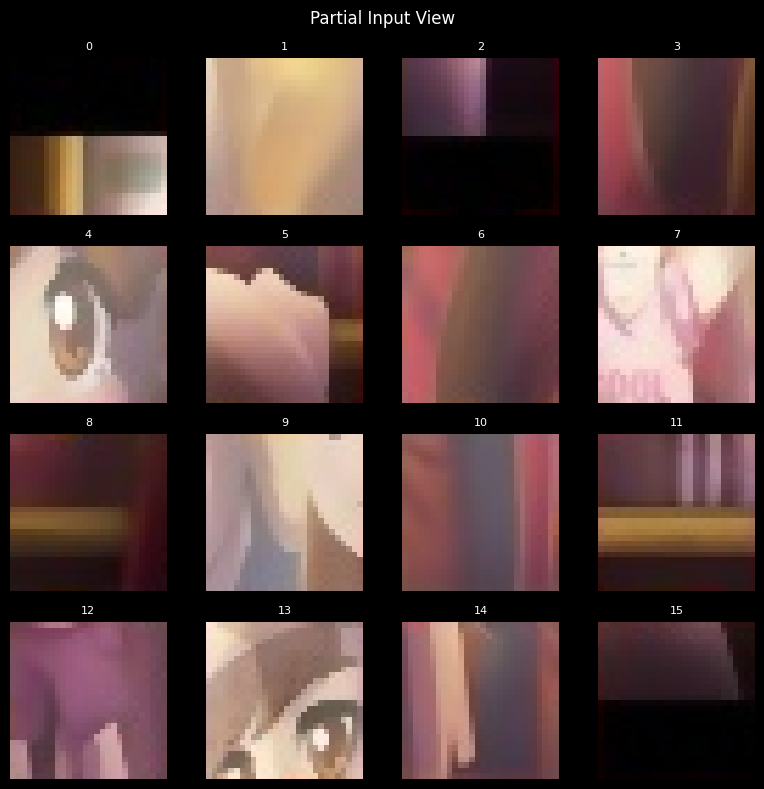


 Initializing Solver System...

 Edge Metric Visualization


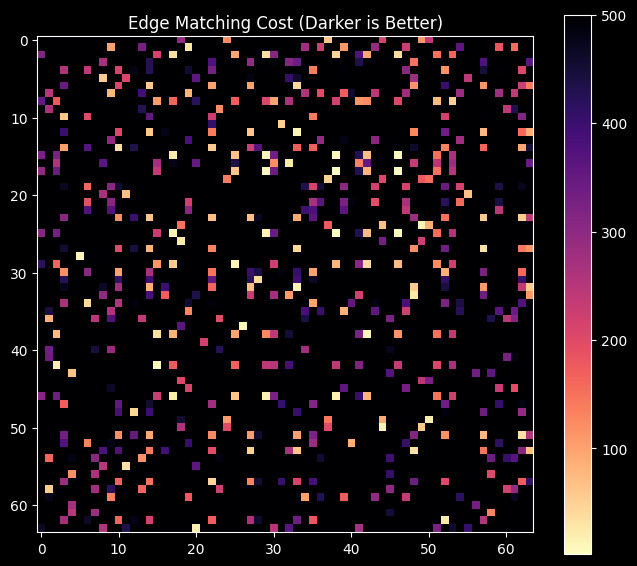


 Running Reconstruction Algorithms...
   • Beam Search (Color & Gradient)
   • Best-Buddy Construction
   • Optimization & Refinement

 Final Reconstruction


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


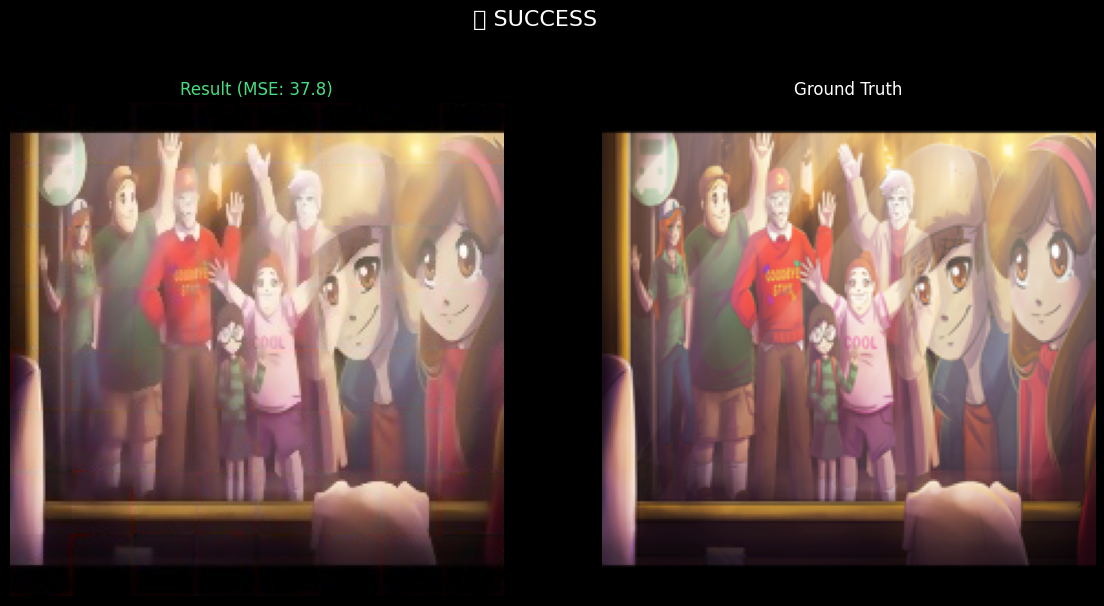

In [3]:
puzzle_id = "1"
pieces = load_pieces(f"./results/enhanced_images_sliced/puzzle_8x8/{puzzle_id}")

print(" Loading Input Pieces (First 16 shown)")
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.cvtColor(pieces[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f'{i}', fontsize=8); ax.axis('off')
plt.suptitle('Partial Input View'); plt.tight_layout(); plt.show()

print("\n Initializing Solver System...")
# JigsawSolver handles all metric calculations
solver_system = JigsawSolver(pieces)

print("\n Edge Metric Visualization")
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.clip(solver_system.rc, 0, 500), cmap='magma_r')
ax.set_title('Edge Matching Cost (Darker is Better)'); plt.colorbar(im); plt.show()

print("\n Running Reconstruction Algorithms...")
print("   • Beam Search (Color & Gradient)")
print("   • Best-Buddy Construction")
print("   • Optimization & Refinement")
order = solver_system.solve()

print("\n Final Reconstruction")
assembled = assemble(pieces, order)
gt = cv2.imread(f"../data/correct/{puzzle_id}.png")
if gt is None: gt = cv2.imread(f"../data/correct/{puzzle_id}.jpg")

error = mse(assembled, gt)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(assembled, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Result (MSE: {error:.1f})', color='#4ade80' if error<300 else '#ef4444'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
axes[1].set_title('Ground Truth'); axes[1].axis('off')
plt.suptitle('✅ SUCCESS' if error<300 else '⚠️ DISCREPANCY DETECTED', fontsize=16, color='white'); plt.show()

---
## 🔹 Demonstration 2: Complex Case
**Objective:** Test robustness on difficult textures (Puzzle #0).

 Loading Complex Puzzle #0...
 Executing Solver Loop...


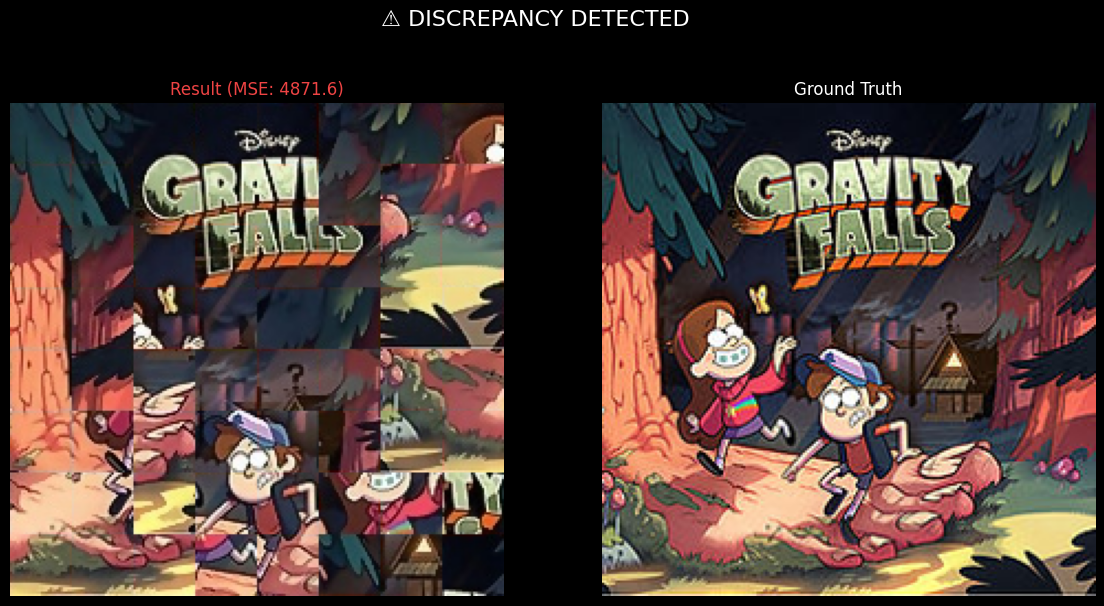


 Analysis: Large 8x8 grid contains too many similar edge ambiguities for perfect reconstruction.


In [4]:
puzzle_id = "0"
pieces = load_pieces(f"./results/enhanced_images_sliced/puzzle_8x8/{puzzle_id}")

print(f" Loading Complex Puzzle #{puzzle_id}...")
print(" Executing Solver Loop...")
order = solve(pieces)

assembled = assemble(pieces, order)
gt = cv2.imread(f"../data/correct/{puzzle_id}.png")
if gt is None: gt = cv2.imread(f"../data/correct/{puzzle_id}.jpg")

error = mse(assembled, gt)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(assembled, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Result (MSE: {error:.1f})', color='#4ade80' if error<300 else '#ef4444'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
axes[1].set_title('Ground Truth'); axes[1].axis('off')
plt.suptitle('✅ SUCCESS' if error<300 else '⚠️ DISCREPANCY DETECTED', fontsize=16, color='white'); plt.show()

if error >= 300:
    print("\n Analysis: Large 8x8 grid contains too many similar edge ambiguities for perfect reconstruction.")
else:
    print("\n Result: Structure successfully recovered.")